# DNN model

## 1. Notebook set-up

In [1]:
# Set notebook root to project root
from helper_functions import set_project_root
set_project_root()

# Silence tensorflow, except for errors
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Run on the GTX1080 GPU - fastest single worker/small memory performance
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Standard library imports
import pickle
import time
import types
from pathlib import Path

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Local imports
import configuration as config
from ariel_data_preprocessing.difference_pair_generator_functions import make_training_datasets

# Make sure the figures directory exists
figures_dir = f'{config.FIGURES_DIRECTORY}/model_training'
Path(figures_dir).mkdir(parents=True, exist_ok=True)

# Make sure models directory exists
Path(config.MODELS_DIRECTORY).mkdir(parents=True, exist_ok=True)

Working directory: /mnt/arkk/kaggle/ariel-data-challenge


## 2. Initialize data generators

In [2]:
training_dataset, validation_dataset, evaluation_dataset = make_training_datasets(
    data_file = f'{config.PROCESSED_DATA_DIRECTORY}/train-1100_smoothing-10-20-40-80-160.h5',
    sample_size = 100,
    standardize_wavelengths=False
)

In [3]:
# training_data = training_dataset.take(50)

# difference_pairs = np.array([element[0].numpy() for element in training_data])
# spectra = np.array([element[1].numpy() for element in training_data])

# print(f'Signals shape: {difference_pairs.shape}')
# print(f'Spectra shape: {spectra.shape}')

## 3. Model definition

In [6]:
def dnn(**hyperparameters) -> tf.keras.Model:

    '''Builds the deep neural network regression model'''

    hyperparameters = types.SimpleNamespace(**hyperparameters)

    # Set-up the L1L2 for the dense layers
    regularizer = tf.keras.regularizers.L1L2(
        l1=hyperparameters.l1,
        l2=hyperparameters.l2
    )

    # Define the model layers in order
    model = [tf.keras.layers.Input((config.WAVELENGTHS))]

    dense_units = hyperparameters.first_layer_dense_units
    
    for _ in range(int(hyperparameters.hidden_layers // 2)):
        model.append(
            tf.keras.layers.Dense(
                dense_units,
                kernel_regularizer=regularizer,
                activation='relu',
            )
        )

        dense_units *= hyperparameters.dense_units_factor
        dense_units = int(dense_units)

    for _ in range(int(hyperparameters.hidden_layers // 2)):
        model.append(
            tf.keras.layers.Dense(
                dense_units,
                kernel_regularizer=regularizer,
                activation='relu',
            )
        )

        dense_units /= hyperparameters.dense_units_factor
        dense_units = int(dense_units)

    model.append(tf.keras.layers.Dense(config.WAVELENGTHS, activation='linear'))

    model = tf.keras.Sequential(model)

    # Define the optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=hyperparameters.learning_rate,
        beta_1=hyperparameters.beta_one,
        beta_2=hyperparameters.beta_two,
        amsgrad=hyperparameters.amsgrad,
        weight_decay=hyperparameters.weight_decay,
        use_ema=hyperparameters.use_ema
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.MeanSquaredError(name='MSE'),
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='RMSE')]
    )

    return model

In [7]:
hyperparameters = {
    'l1': 1e-6,
    'l2': 1e-6,
    'first_layer_dense_units': 64,
    'hidden_layers': 6,
    'dense_units_factor': 2,
    'learning_rate': 1e-6,
    'beta_one': 0.9,
    'beta_two': 0.999,
    'amsgrad': False,
    'weight_decay': 0.0,
    'use_ema': False
}

model = dnn(**hyperparameters)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                18176     
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 256)               33024     
                                                                 
 dense_3 (Dense)             (None, 512)               131584    
                                                                 
 dense_4 (Dense)             (None, 256)               131328    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 283)              

## 3. Single training run

In [8]:
batch_size = 1
epochs = 1000
steps = 100
total_ksteps = 1000 * (steps * epochs * batch_size) // 1000

# model_save_file = f'{config.MODELS_DIRECTORY}/ariel_dnn-0.1M-{total_ksteps}ksteps-tf2.11.keras'
# training_results_save_file = f'{config.MODELS_DIRECTORY}/ariel_dnn-0.1M-{total_ksteps}ksteps.pkl'

# if Path(model_save_file).exists() and Path(training_results_save_file).exists():

#     print(f'Found existing model for {total_ksteps} ksteps, skipping training.')

#     # Load the existing model
#     model = tf.keras.models.load_model(model_save_file)

#     # Load existing training results
#     with open(training_results_save_file, 'rb') as input_file:
#         training_results = pickle.load(input_file)

# else:

print(f'Training model for {total_ksteps} ksteps')
start_time = time.time()

training_results = model.fit(
  training_dataset.batch(batch_size),
  validation_data=validation_dataset.batch(batch_size),
  epochs=epochs,
  steps_per_epoch=steps,
  validation_steps=steps,
  verbose=1
)

  # print(f'Training complete in {(time.time() - start_time)/60:.1f} minutes')
  # model.save(model_save_file)

  # with open(training_results_save_file, 'wb') as output_file:
  #     pickle.dump(training_results, output_file)

Training model for 100000 ksteps
Epoch 1/1000


100/100 [==============================] - 7s 16ms/step - loss: 2637.3010 - RMSE: 51.3545 - val_loss: 1658.3811 - val_RMSE: 40.7230
Epoch 2/1000
100/100 [==============================] - 1s 12ms/step - loss: 659.3792 - RMSE: 25.6780 - val_loss: 3338.6418 - val_RMSE: 57.7808
Epoch 3/1000
100/100 [==============================] - 1s 13ms/step - loss: 3072.4243 - RMSE: 55.4293 - val_loss: 964.5803 - val_RMSE: 31.0574
Epoch 4/1000
100/100 [==============================] - 1s 13ms/step - loss: 639.7868 - RMSE: 25.2936 - val_loss: 2810.2815 - val_RMSE: 53.0119
Epoch 5/1000
100/100 [==============================] - 1s 13ms/step - loss: 1024.3414 - RMSE: 32.0050 - val_loss: 1219.5277 - val_RMSE: 34.9215
Epoch 6/1000
100/100 [==============================] - 1s 12ms/step - loss: 688.7689 - RMSE: 26.2440 - val_loss: 6050.5244 - val_RMSE: 77.7850
Epoch 7/1000
100/100 [==============================] - 1s 13ms/step - loss: 622.9700 - RMSE: 24.9590 - val_loss: 2776.5076 - val_RMSE: 52.6924
Epo

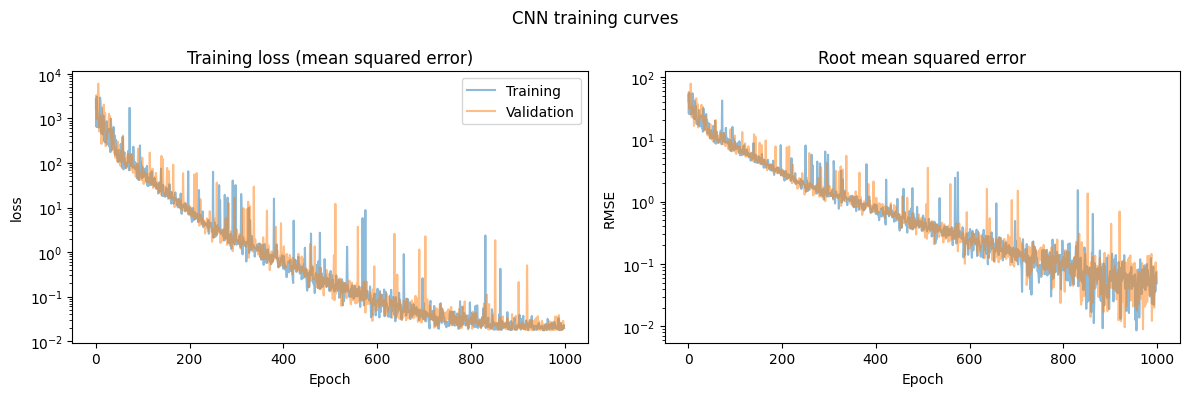

In [9]:
# Set-up a 1x2 figure for accuracy and binary cross-entropy
fig, axs=plt.subplots(1,2, figsize=(12,4))

# Add the main title
fig.suptitle('CNN training curves', size='large')

# Plot training and validation loss
axs[0].set_title('Training loss (mean squared error)')
axs[0].plot(np.array(training_results.history['loss']), alpha=0.5, label='Training')
axs[0].plot(np.array(training_results.history['val_loss']), alpha=0.5, label='Validation')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('loss')
# axs[0].set_ylim(21, 25)
axs[0].set_yscale('log')
axs[0].legend(loc='upper right')

# Plot training and validation RMSE
axs[1].set_title('Root mean squared error')
axs[1].plot(training_results.history['RMSE'], alpha=0.5, label='Training')
axs[1].plot(training_results.history['val_RMSE'], alpha=0.5, label='Validation')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('RMSE')
# axs[2].set_ylim(top=0.014)
axs[1].set_yscale('log')

# Show the plot
fig.tight_layout()
fig.savefig(
    f'{figures_dir}/03.4.1-ariel_dnn_training_curves_0.3M-{total_ksteps}ksteps.jpg',
    dpi=config.STD_FIG_DPI,
    bbox_inches='tight'
)